# Germany Housing Prices — Exploratory Data Analysis

Dataset: synthetic but realistic German housing market data across 11 major cities.  
Features: city, state, property type, price (EUR), size (sqm), rooms, year built, distance to city center, price per sqm.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

df = pd.read_csv('data/data.csv')
print(df.shape)
df.head()

Matplotlib is building the font cache; this may take a moment.


(120, 9)


,city,state,property_type,price_eur,size_sqm,rooms,year_built,distance_to_center_km,price_per_sqm
0,München,Bavaria,Apartment,620000,72,3,2010,2.1,8611
1,München,Bavaria,Apartment,850000,95,4,2018,1.4,8947
2,München,Bavaria,House,1450000,160,6,2005,8.3,9063
3,München,Bavaria,Apartment,480000,58,2,1998,3.7,8276
4,München,Bavaria,House,1750000,185,7,2015,6.1,9459


In [2]:
df.describe()

,price_eur,size_sqm,rooms,year_built,distance_to_center_km,price_per_sqm
count,1.200000e+02,120.000000,120.000000,120.000000,120.00000,120.000000
mean,5.053333e+05,102.541667,3.841667,2008.166667,5.87750,4820.558333
std,3.313575e+05,46.325827,1.593030,9.243061,2.90052,1715.372076
min,1.200000e+05,46.000000,2.000000,1985.000000,1.40000,2400.000000
25%,2.675000e+05,62.000000,2.000000,2003.000000,3.17500,3400.000000
50%,4.250000e+05,85.000000,3.500000,2010.000000,5.75000,4641.000000
75%,6.500000e+05,148.500000,5.000000,2015.000000,8.70000,5879.000000
max,2.100000e+06,220.000000,8.000000,2022.000000,11.50000,9545.000000


## 1. Average price per sqm by city

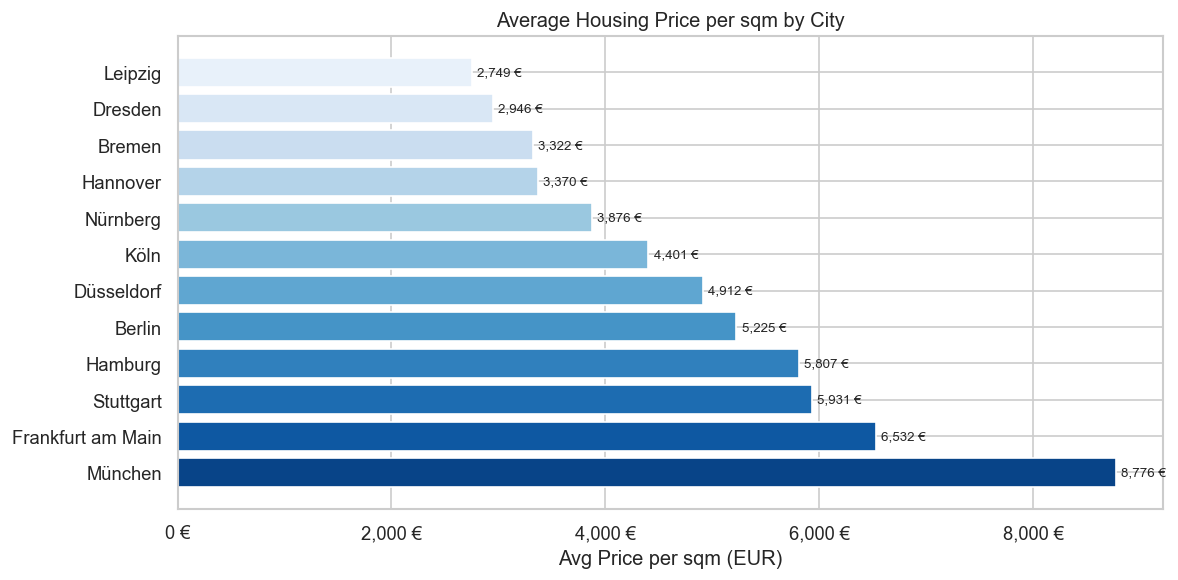

In [3]:
city_avg = (
    df.groupby('city')['price_per_sqm']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(city_avg['city'], city_avg['price_per_sqm'], color=sns.color_palette('Blues_r', len(city_avg)))
ax.set_xlabel('Avg Price per sqm (EUR)')
ax.set_title('Average Housing Price per sqm by City')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f} €'))
for bar, val in zip(bars, city_avg['price_per_sqm']):
    ax.text(val + 50, bar.get_y() + bar.get_height() / 2, f'{val:,.0f} €', va='center', fontsize=8)
plt.tight_layout()
plt.show()

## 2. Price distribution by property type

/var/folders/59/mvn9gjbd6j58_2wtfbfkjx_c0000gp/T/ipykernel_8100/3335625228.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='property_type', y='price_eur', ax=axes[0], palette='Set2')
/var/folders/59/mvn9gjbd6j58_2wtfbfkjx_c0000gp/T/ipykernel_8100/3335625228.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='property_type', y='price_per_sqm', ax=axes[1], palette='Set2')


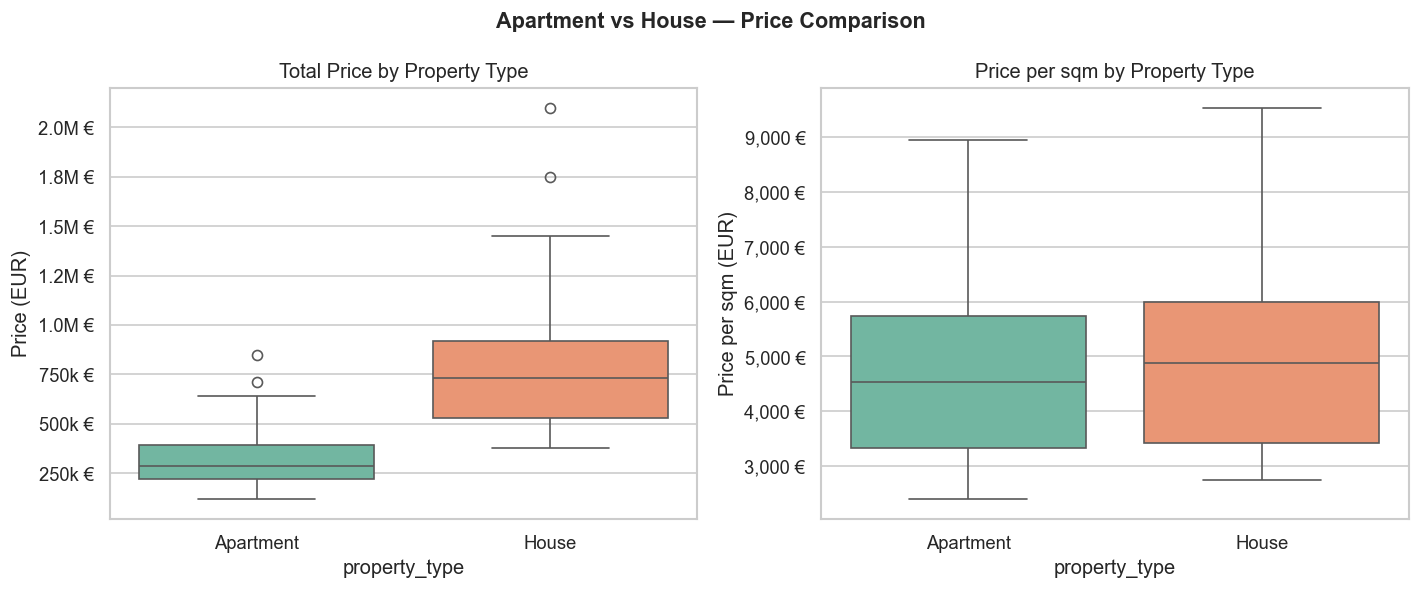

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Box plot — total price
sns.boxplot(data=df, x='property_type', y='price_eur', ax=axes[0], palette='Set2')
axes[0].set_title('Total Price by Property Type')
axes[0].set_ylabel('Price (EUR)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M €' if x >= 1e6 else f'{x/1e3:.0f}k €'))

# Box plot — price per sqm
sns.boxplot(data=df, x='property_type', y='price_per_sqm', ax=axes[1], palette='Set2')
axes[1].set_title('Price per sqm by Property Type')
axes[1].set_ylabel('Price per sqm (EUR)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f} €'))

plt.suptitle('Apartment vs House — Price Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Price vs size (coloured by city)

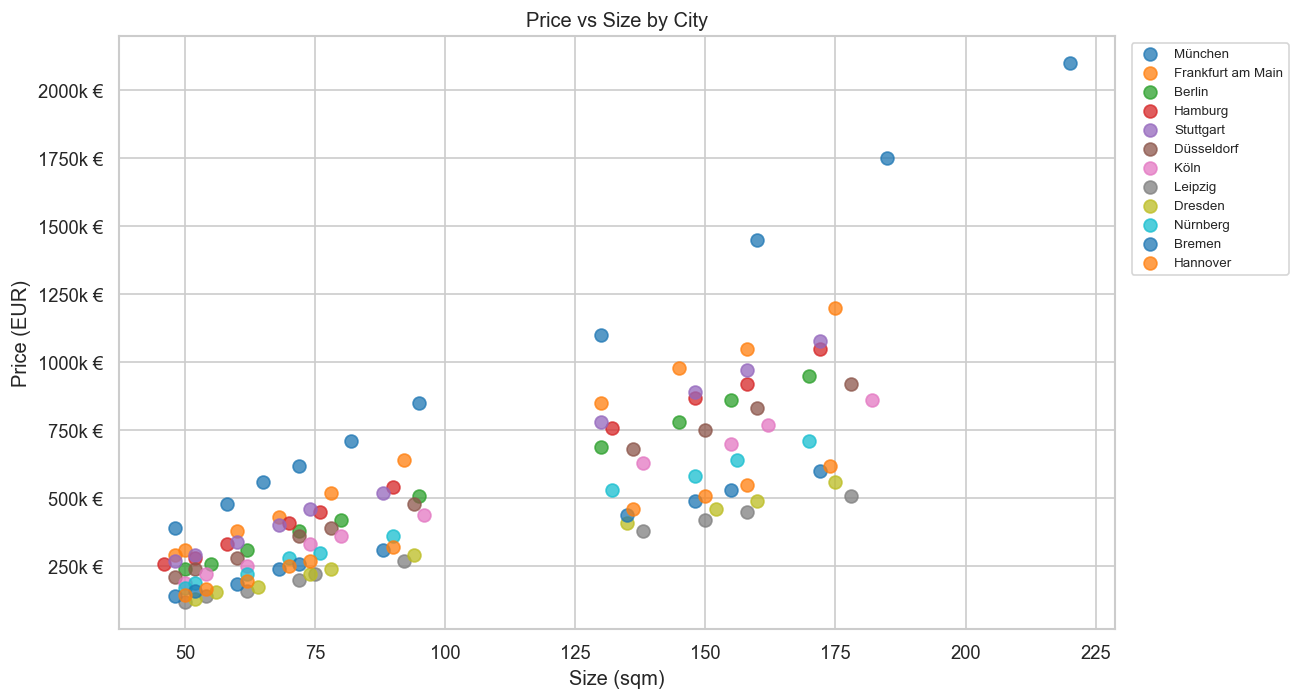

In [5]:
fig, ax = plt.subplots(figsize=(11, 6))
cities = df['city'].unique()
palette = sns.color_palette('tab10', len(cities))

for city, color in zip(cities, palette):
    subset = df[df['city'] == city]
    ax.scatter(subset['size_sqm'], subset['price_eur'], label=city, color=color, alpha=0.75, s=60)

ax.set_xlabel('Size (sqm)')
ax.set_ylabel('Price (EUR)')
ax.set_title('Price vs Size by City')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k €'))
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

## 4. Price per sqm vs distance to city center

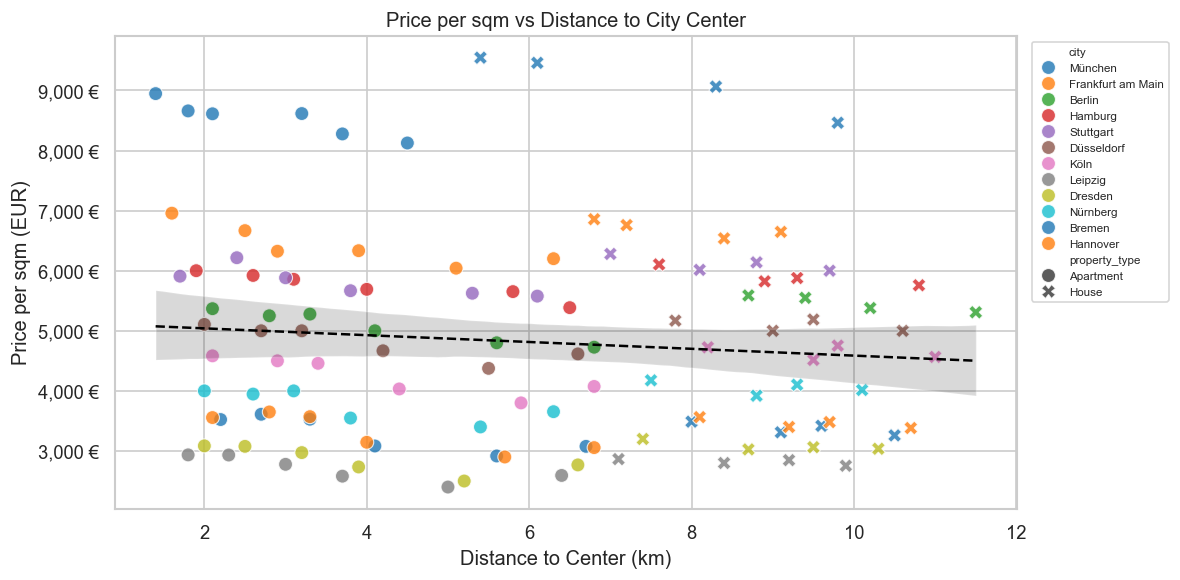

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.scatterplot(data=df, x='distance_to_center_km', y='price_per_sqm', hue='city',
                style='property_type', palette='tab10', s=70, alpha=0.8, ax=ax)
sns.regplot(data=df, x='distance_to_center_km', y='price_per_sqm',
            scatter=False, color='black', line_kws={'linewidth': 1.5, 'linestyle': '--'}, ax=ax)
ax.set_title('Price per sqm vs Distance to City Center')
ax.set_xlabel('Distance to Center (km)')
ax.set_ylabel('Price per sqm (EUR)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f} €'))
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=7)
plt.tight_layout()
plt.show()

## 5. Average price per sqm by city and property type (heatmap)

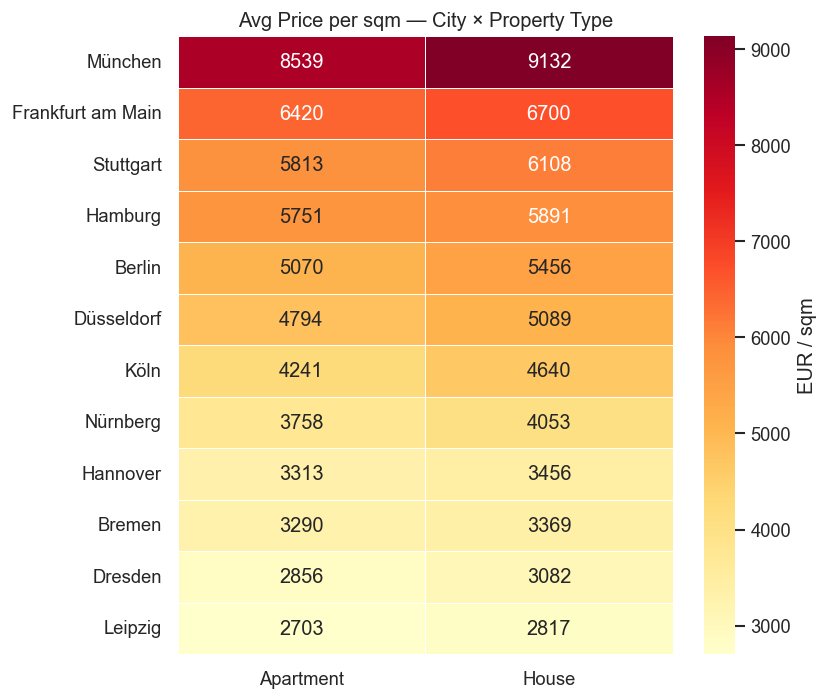

In [7]:
pivot = df.pivot_table(values='price_per_sqm', index='city', columns='property_type', aggfunc='mean')
pivot = pivot.sort_values('Apartment', ascending=False)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5,
            cbar_kws={'label': 'EUR / sqm'}, ax=ax)
ax.set_title('Avg Price per sqm — City × Property Type')
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

## 6. Price trend by year built

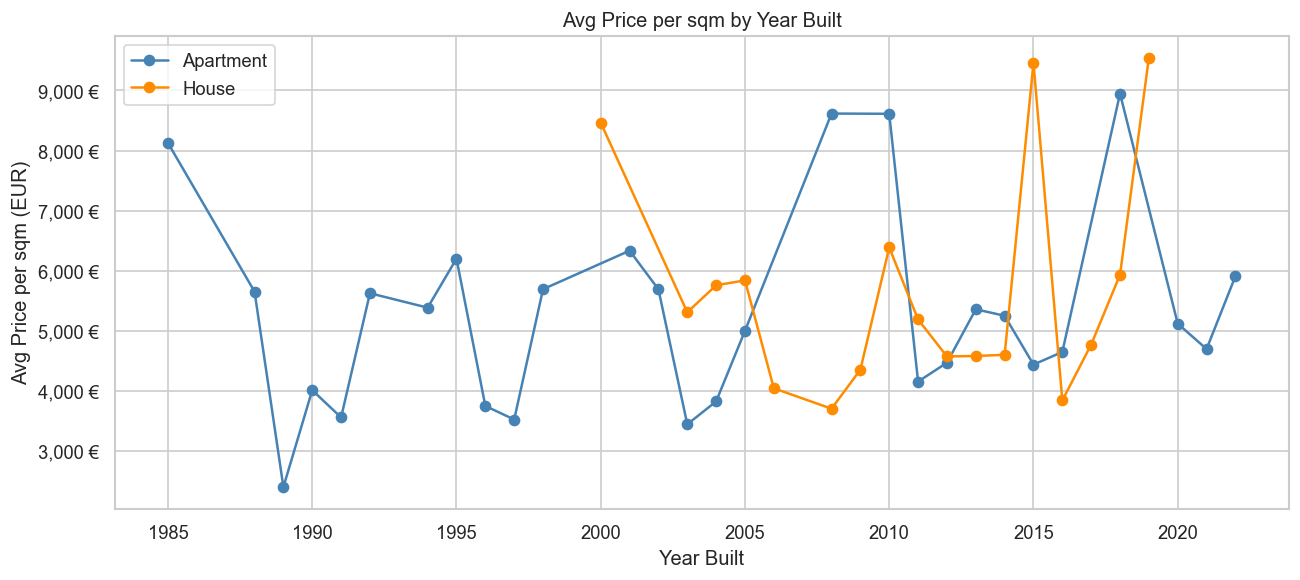

In [8]:
year_avg = df.groupby(['year_built', 'property_type'])['price_per_sqm'].mean().reset_index()

fig, ax = plt.subplots(figsize=(11, 5))
for ptype, color in zip(['Apartment', 'House'], ['steelblue', 'darkorange']):
    subset = year_avg[year_avg['property_type'] == ptype]
    ax.plot(subset['year_built'], subset['price_per_sqm'], marker='o', label=ptype, color=color)

ax.set_title('Avg Price per sqm by Year Built')
ax.set_xlabel('Year Built')
ax.set_ylabel('Avg Price per sqm (EUR)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f} €'))
ax.legend()
plt.tight_layout()
plt.show()

## 7. Correlation heatmap

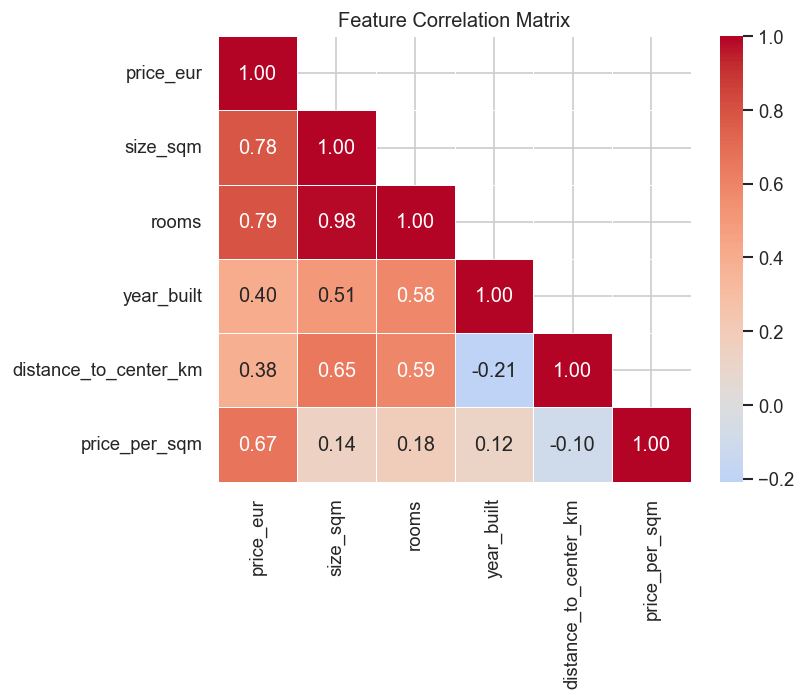

In [9]:
numeric_cols = ['price_eur', 'size_sqm', 'rooms', 'year_built', 'distance_to_center_km', 'price_per_sqm']
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(7, 6))
mask = pd.DataFrame(False, index=corr.index, columns=corr.columns)
import numpy as np
mask.values[np.triu_indices_from(mask.values, k=1)] = True
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            mask=mask, linewidths=0.5, ax=ax)
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()